# Auditoria visual offline ROI-aware

Resumen ejecutivo de la corrida sanity y de `policy_moderate_v2` como candidato preliminar.

In [1]:
from IPython.display import Image, Markdown, display

from data_cleaning.src.visual_quality_notebook_utils import (
    analizar_wer_cer,
    cargar_tablas_auditoria,
    conclusion_presentacion,
    formato_predicciones_futuras,
    generar_sheet_presentacion,
    resumen_ejecutivo,
    resumen_muestra_vsr,
    tabla_retenciones,
    top_reasons,
)

tablas = cargar_tablas_auditoria()
ROOT = tablas["root"]
sanity = tablas["sanity"]
policy = tablas["policy"]
policy_v1 = tablas["policy_v1"]
sample = tablas["sample"]
preview_dir = ROOT / "data_cleaning" / "outputs" / "visual_quality_audit" / "presentation_examples"

## Estado de inputs y retencion

In [2]:
display(resumen_ejecutivo(sanity, policy, policy_v1))
display(tabla_retenciones(policy, policy_v1))

,metric,value
0,clips,5950
1,input_kind,{'roi_npz': 5950}
2,run_mode,{'roi_audit': 5950}
3,roi_coverage,100.00%
4,decision_sanity,"{'keep': 3343, 'review': 2607}"
5,review_severity_v2,"{'none': 3331, 'medium': 1082, 'high': 810, 'l..."
6,training_usability,"{'usable': 3330, 'questionable': 2402, 'bad_ca..."
7,policy_conservative_v2,"{'policy': 'policy_conservative', 'keep': 5950..."
8,policy_moderate_v2,"{'policy': 'policy_moderate', 'keep': 5732, 'e..."
9,policy_strict_v2,"{'policy': 'policy_strict', 'keep': 3830, 'exc..."


,version,policy,keep,exclude,retention_pct
0,v2,policy_conservative,5950,0,100.00
1,v2,policy_moderate,5732,218,96.34
2,v2,policy_strict,3830,2120,64.37
3,v1,policy_moderate,5140,810,86.39


## Senales usadas y separadas

In [3]:
display(top_reasons(sanity, "used_for_decision_reasons", top=12))
display(top_reasons(sanity, "non_applicable_reasons", top=12))
display(top_reasons(policy, "training_usability_reasons", top=12))

,reason,clips
0,corte_escena,1212
1,blur,1158
2,blur_extremo,757
3,baja_textura_boca,463
4,contraste_bajo,199
5,boca_inactiva,54
6,boca_tapada_o_poco_visible,1


,reason,clips
0,face_detector_haar_alerta,5950
1,pose_proxy_haar,5950
2,multiples_caras,5950
3,rostro_inestable_o_no_detectado,5950
4,cambio_cara_dominante,5950
5,perfil_extremo,5950
6,face_tracking_proxy,5950
7,speaker_mismatch_proxy,5950
8,riesgo_boca_texto_o_hablante,5950


,reason,clips
0,mouth_visible,5940
1,blur_low_texture,1917
2,scene_discontinuity,1213
3,quality_tail,595
4,low_mouth_motion,54
5,mouth_occluded_many_frames,1
6,roi_unstable_or_bad_crop,1
7,side_profile_or_partial_mouth,1


## Ejemplos representativos

,source_id,clip,policy_moderate,training_usability,training_usability_reasons,quality_score,mouth_activity_score,mouth_visibility_score,scene_cut_score,blur_score
0,DAVOO XENEIZE OPINA DE BOCA 0 UNIVERSIDAD CATO...,clip_0493,keep,usable,mouth_visible,1.0000,1.0000,1.0000,0.0,1.0
1,ANÉCDOTA VIAJE MUNDIAL BRASIL 2014 parte 1,clip_0301,keep,questionable,mouth_visible;blur_low_texture;quality_tail,0.6246,0.6687,0.5298,0.0,0.0
2,Las y los estudiantes al frente - Entrevista a la,clip_0224,exclude,bad_candidate,mouth_occluded_many_frames;roi_unstable_or_bad...,0.4937,1.0000,0.1530,1.0,0.0
3,PROFESIONES ARGENTINAS GOMEROS - Telefe Noticias,clip_0028,keep,questionable,mouth_visible;blur_low_texture;quality_tail,0.4937,0.4593,0.4381,0.0,0.0


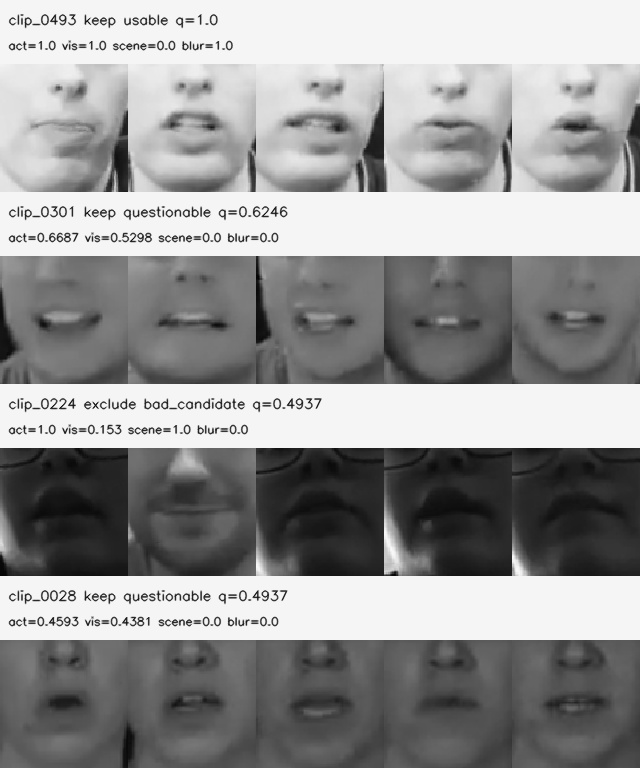

In [4]:
examples, image = generar_sheet_presentacion(policy, preview_dir)
display(examples)
if image:
    display(Image(filename=str(image)))

## WER/CER, muestra VSR y conclusion

In [5]:
wer = analizar_wer_cer(policy)
display(wer["resumen"])
display(resumen_muestra_vsr(sample))
display(formato_predicciones_futuras())
display(Markdown(conclusion_presentacion(policy, wer["impact"], sample)))

,candidate,matched,policy_moderate_counts,comparable,warning
0,"{'tipo': 'inf_ref_hyp_con_mapeo', 'path': 'vsr...",148,{'keep': 148},False,WER actual no valida policy_moderate porque lo...


,metric,value
0,clips,300
1,policy_moderate_v2,"{'keep': 200, 'exclude': 100}"
2,training_usability,"{'bad_candidate': 100, 'questionable': 100, 'u..."
3,split,"{'train': 258, 'val': 30, 'test': 12}"
4,fuentes,31


,columna,descripcion
0,source_id,fuente/titulo del manifest
1,clip,clip_NNNN original
2,split,split de la muestra
3,reference,texto esperado
4,hypothesis,salida VSR
5,wer,"WER por clip, fraccion 0-1"
6,cer,"CER por clip, fraccion 0-1"


No entrenar todavia con un filtro visual final: falta medir impacto VSR barato por grupo.  
policy_moderate_v2 retiene 96.34% (5732 clips) y excluye 218 bad_candidate.  
policy_strict_v2 retiene 64.37% y queda solo como analisis de sensibilidad.  
WER/CER actual no valida excludes: la muestra estratificada es el siguiente insumo.  
Muestra VSR disponible: 300 clips en data/metadata/visual_quality_vsr_eval_sample.csv.